<a href="https://colab.research.google.com/github/yunussfr/regression-and-classification-fields-of-study/blob/main/RenderBikePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, PoissonRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print("Kütüphaneler hazır.")

Kütüphaneler hazır.


In [3]:
import pandas as pd

# Veri setinin UCI üzerindeki adresi
DATA_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00560/SeoulBikeData.csv"
)

# CSV dosyasını okuyarak DataFrame'e dönüştürüyoruz
df = pd.read_csv(DATA_URL, encoding="ISO-8859-1")

# Veri setinin boyutunu yazdırıyoruz
print("Veri setinin boyutu:", df.shape)

# İlk 5 gözlemi gösteriyoruz
display(df.head(34))


Veri setinin boyutu: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.200,37,2.200,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.500,38,0.800,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.000,39,1.000,2000,-17.700,0.000,0.000,0.000,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.200,40,0.900,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.000,36,2.300,2000,-18.600,0.000,0.000,0.000,Winter,No Holiday,Yes
5,01/12/2017,100,5,-6.400,37,1.500,2000,-18.700,0.000,0.000,0.000,Winter,No Holiday,Yes
6,01/12/2017,181,6,-6.600,35,1.300,2000,-19.500,0.000,0.000,0.000,Winter,No Holiday,Yes
7,01/12/2017,460,7,-7.400,38,0.900,2000,-19.300,0.000,0.000,0.000,Winter,No Holiday,Yes
8,01/12/2017,930,8,-7.600,37,1.100,2000,-19.800,0.010,0.000,0.000,Winter,No Holiday,Yes
9,01/12/2017,490,9,-6.500,27,0.500,1928,-22.400,0.230,0.000,0.000,Winter,No Holiday,Yes


In [4]:

print(df.columns.tolist())

['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

hiç boş veri yok


In [6]:
sayisal_sutunlar = df.select_dtypes(include="number").columns.tolist()
kategorik_sutunlar = df.select_dtypes(exclude="number").columns.tolist()

print("Sayısal sütunlar:")
print(sayisal_sutunlar)

print("\nKategorik sütunlar:")
print(kategorik_sutunlar)

Sayısal sütunlar:
['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

Kategorik sütunlar:
['Date', 'Seasons', 'Holiday', 'Functioning Day']


verilerimiz yapılarını görmüş olduk

In [7]:
tekrar_eden_satir_sayisi = df.duplicated().sum()

print("Tekrar eden satır sayısı:", tekrar_eden_satir_sayisi)

Tekrar eden satır sayısı: 0


In [8]:
print("Orijinal sütunlar:")
print(df.columns.tolist())

standard_columns = [
    "date",
    "rented_bike_count",
    "hour",
    "temperature_c",
    "humidity_pct",
    "wind_speed_m_s",
    "visibility_10m",
    "dew_point_temperature_c",
    "solar_radiation_mj_m2",
    "rainfall_mm",
    "snowfall_cm",
    "season",
    "holiday",
    "functioning_day",
]

if df.shape[1] != len(standard_columns):
    raise ValueError(
        f"Beklenen sütun sayısı {len(standard_columns)}, "
        f"fakat veri setinde {df.shape[1]} sütun var."
    )

df.columns = standard_columns

print("\nStandartlaştırılmış sütunlar:")
print(df.columns.tolist())
display(df.head())


Orijinal sütunlar:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']

Standartlaştırılmış sütunlar:
['date', 'rented_bike_count', 'hour', 'temperature_c', 'humidity_pct', 'wind_speed_m_s', 'visibility_10m', 'dew_point_temperature_c', 'solar_radiation_mj_m2', 'rainfall_mm', 'snowfall_cm', 'season', 'holiday', 'functioning_day']


,date,rented_bike_count,hour,temperature_c,humidity_pct,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,season,holiday,functioning_day
0,01/12/2017,254,0,-5.200,37,2.200,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.500,38,0.800,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.000,39,1.000,2000,-17.700,0.000,0.000,0.000,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.200,40,0.900,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.000,36,2.300,2000,-18.600,0.000,0.000,0.000,Winter,No Holiday,Yes


In [9]:
print("\nSeason dağılımı:")
display(df["season"].value_counts(dropna=False).to_frame("count"))

print("\nHoliday dağılımı:")
display(df["holiday"].value_counts(dropna=False).to_frame("count"))

print("\nFunctioning day dağılımı:")
display(df["functioning_day"].value_counts(dropna=False).to_frame("count"))

print("\nSayısal özet:")
display(df.describe(include="number").T)



Season dağılımı:


,count
season,
Spring,2208
Summer,2208
Autumn,2184
Winter,2160



Holiday dağılımı:


,count
holiday,
No Holiday,8328
Holiday,432



Functioning day dağılımı:


,count
functioning_day,
Yes,8465
No,295



Sayısal özet:


,count,mean,std,min,25%,50%,75%,max
rented_bike_count,"8,760.000",704.602,644.997,0.000,191.000,504.500,"1,065.250","3,556.000"
hour,"8,760.000",11.500,6.923,0.000,5.750,11.500,17.250,23.000
temperature_c,"8,760.000",12.883,11.945,-17.800,3.500,13.700,22.500,39.400
humidity_pct,"8,760.000",58.226,20.362,0.000,42.000,57.000,74.000,98.000
wind_speed_m_s,"8,760.000",1.725,1.036,0.000,0.900,1.500,2.300,7.400
visibility_10m,"8,760.000","1,436.826",608.299,27.000,940.000,"1,698.000","2,000.000","2,000.000"
dew_point_temperature_c,"8,760.000",4.074,13.060,-30.600,-4.700,5.100,14.800,27.200
solar_radiation_mj_m2,"8,760.000",0.569,0.869,0.000,0.000,0.010,0.930,3.520
rainfall_mm,"8,760.000",0.149,1.128,0.000,0.000,0.000,0.000,35.000
snowfall_cm,"8,760.000",0.075,0.437,0.000,0.000,0.000,0.000,8.800


In [10]:
df["date"] = pd.to_datetime(
    df["date"],
    dayfirst=True,
    errors="coerce"
)

invalid_date_count = int(df["date"].isna().sum())

if invalid_date_count > 0:
    raise ValueError(
        f"{invalid_date_count} tarih değeri dönüştürülemedi."
    )

before_drop = len(df)
df = df.drop_duplicates().copy()
removed_duplicates = before_drop - len(df)

df = (
    df.sort_values(["date", "hour"])
      .reset_index(drop=True)
)

print("Kaldırılan tekrar sayısı:", removed_duplicates)
print("En erken tarih:", df["date"].min())
print("En geç tarih:", df["date"].max())
print("Temizlik sonrası boyut:", df.shape)

display(df.head())


Kaldırılan tekrar sayısı: 0
En erken tarih: 2017-12-01 00:00:00
En geç tarih: 2018-11-30 00:00:00
Temizlik sonrası boyut: (8760, 14)


,date,rented_bike_count,hour,temperature_c,humidity_pct,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,season,holiday,functioning_day
0,2017-12-01,254,0,-5.200,37,2.200,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.500,38,0.800,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.000,39,1.000,2000,-17.700,0.000,0.000,0.000,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.200,40,0.900,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.000,36,2.300,2000,-18.600,0.000,0.000,0.000,Winter,No Holiday,Yes


In [11]:
functioning_normalized = (
    df["functioning_day"]
    .astype(str)
    .str.strip()
    .str.lower()
)

functional_labels = {"yes"}
functional_mask = functioning_normalized.isin(functional_labels)

if not functional_mask.any():
    raise ValueError(
        "Çalışan gün etiketi bulunamadı. "
        f"Mevcut değerler: {df['functioning_day'].unique().tolist()}"
    )

model_df = df.loc[functional_mask].copy()
model_df = model_df.drop(columns="functioning_day")

print("Filtre öncesi satır sayısı:", len(df))
print("Filtre sonrası satır sayısı:", len(model_df))
print("Kaldırılan çalışmayan saat sayısı:", len(df) - len(model_df))

display(model_df.head())


Filtre öncesi satır sayısı: 8760
Filtre sonrası satır sayısı: 8465
Kaldırılan çalışmayan saat sayısı: 295


,date,rented_bike_count,hour,temperature_c,humidity_pct,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,season,holiday
0,2017-12-01,254,0,-5.200,37,2.200,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday
1,2017-12-01,204,1,-5.500,38,0.800,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday
2,2017-12-01,173,2,-6.000,39,1.000,2000,-17.700,0.000,0.000,0.000,Winter,No Holiday
3,2017-12-01,107,3,-6.200,40,0.900,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday
4,2017-12-01,78,4,-6.000,36,2.300,2000,-18.600,0.000,0.000,0.000,Winter,No Holiday


In [12]:
model_df["day_of_week"] = model_df["date"].dt.day_name()

model_df["is_weekend"] = np.where(
    model_df["date"].dt.dayofweek >= 5,
    "Yes",
    "No",
)

model_df["day_of_year"] = model_df["date"].dt.dayofyear

model_df["day_of_year_sin"] = np.sin(
    2 * np.pi * model_df["day_of_year"] / 365.25
)

model_df["day_of_year_cos"] = np.cos(
    2 * np.pi * model_df["day_of_year"] / 365.25
)

model_df["days_since_start"] = (
    model_df["date"] - model_df["date"].min()
).dt.days

display(
    model_df[
        [
            "date",
            "hour",
            "day_of_week",
            "is_weekend",
            "day_of_year",
            "day_of_year_sin",
            "day_of_year_cos",
            "days_since_start",
        ]
    ].head()
)

,date,hour,day_of_week,is_weekend,day_of_year,day_of_year_sin,day_of_year_cos,days_since_start
0,2017-12-01,0,Friday,No,335,-0.497,0.868,0
1,2017-12-01,1,Friday,No,335,-0.497,0.868,0
2,2017-12-01,2,Friday,No,335,-0.497,0.868,0
3,2017-12-01,3,Friday,No,335,-0.497,0.868,0
4,2017-12-01,4,Friday,No,335,-0.497,0.868,0


Tarih tek başına modele doğrudan verilmez.Bunun yerine modelin kullanabileceği takvim özellikleri çıkartılır...
Kullanılan önemli bilgilerin açıklanması:
sinüs ve kosinüs yılın 365. günü ile 1. günü sayısal olarka uzak görünür fakat gerçekte hemen ard arda günlerdir bunları modele gösterebilmek için kullanılmıştır.
bisiklet talepi gün içinde tek ve düzgün bir sinüs dalgası izlemez.Sabah ve akşam olmak üzere tavan noktaları bulunur.Saati One-Hot-Encoding ile kategörik kullanmak,her saatin etkisinin ayrı öğrenilmesini sağlar.

,rented_bike_count
count,"8,465.000"
mean,729.157
std,642.351
min,2.000
25%,214.000
50%,542.000
75%,"1,084.000"
max,"3,556.000"


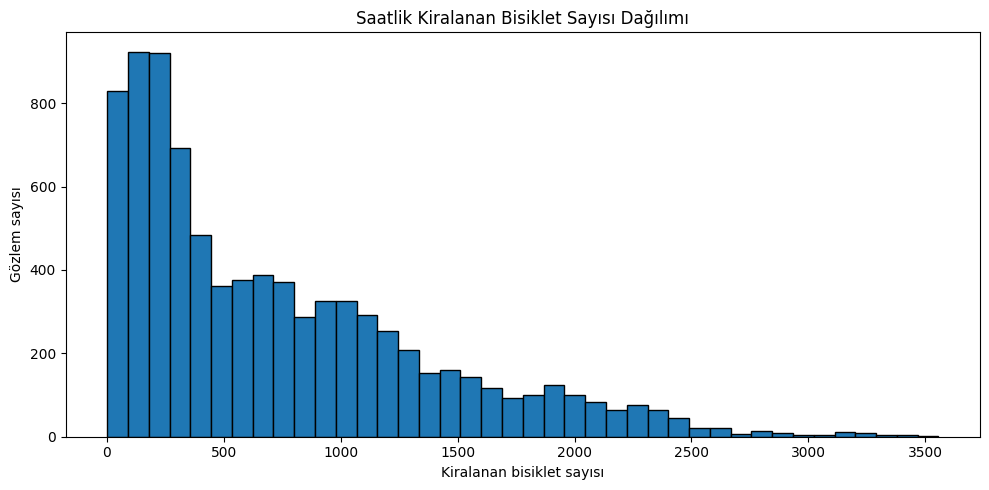

In [13]:
display(
    model_df["rented_bike_count"]
    .describe()
    .to_frame("rented_bike_count")
)

plt.figure(figsize=(10, 5))
plt.hist(
    model_df["rented_bike_count"],
    bins=40,
    edgecolor="black"
)
plt.title("Saatlik Kiralanan Bisiklet Sayısı Dağılımı")
plt.xlabel("Kiralanan bisiklet sayısı")
plt.ylabel("Gözlem sayısı")
plt.tight_layout()
plt.show()


,hour,rented_bike_count
0,0,561.457
1,1,441.923
2,2,312.770
3,3,210.841
4,4,137.489
5,5,144.219
6,6,298.185
7,7,626.606
8,8,"1,050.229"
9,9,667.943


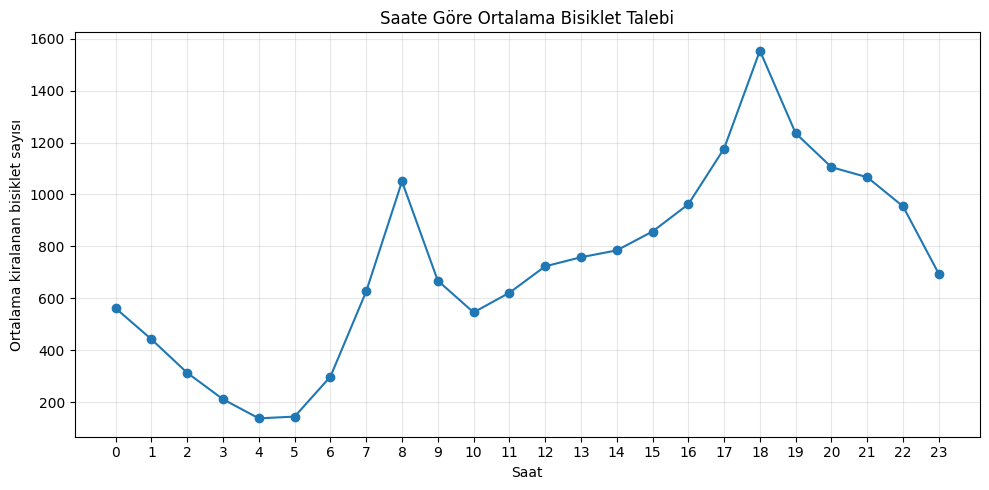

,season,rented_bike_count
2,Summer,"1,034.073"
0,Autumn,924.110
1,Spring,746.254
3,Winter,225.541


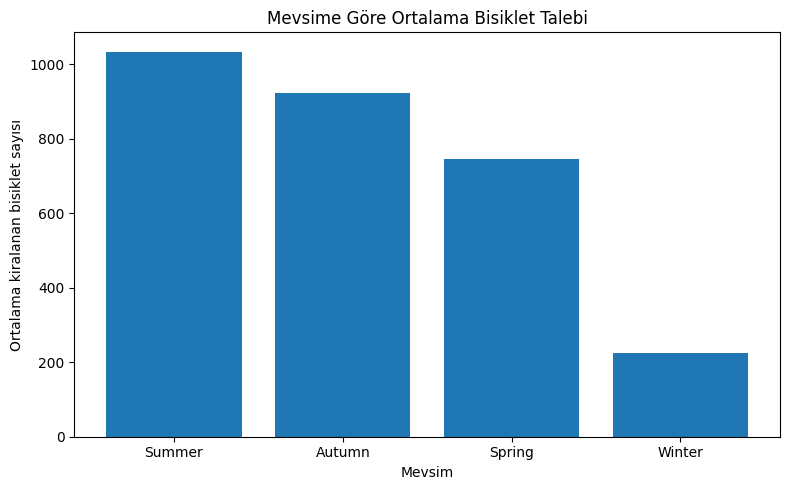

In [14]:
hourly_demand = (
    model_df.groupby("hour", as_index=False)["rented_bike_count"]
    .mean()
)

display(hourly_demand)

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_demand["hour"],
    hourly_demand["rented_bike_count"],
    marker="o"
)
plt.title("Saate Göre Ortalama Bisiklet Talebi")
plt.xlabel("Saat")
plt.ylabel("Ortalama kiralanan bisiklet sayısı")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

seasonal_demand = (
    model_df.groupby("season", as_index=False)["rented_bike_count"]
    .mean()
    .sort_values("rented_bike_count", ascending=False)
)

display(seasonal_demand)

plt.figure(figsize=(8, 5))
plt.bar(
    seasonal_demand["season"],
    seasonal_demand["rented_bike_count"]
)
plt.title("Mevsime Göre Ortalama Bisiklet Talebi")
plt.xlabel("Mevsim")
plt.ylabel("Ortalama kiralanan bisiklet sayısı")
plt.tight_layout()
plt.show()


,monthly_mean_demand
date,
2017-12-31,249.099
2018-01-31,201.621
2018-02-28,225.942
2018-03-31,511.551
2018-04-30,753.200
2018-05-31,982.067
2018-06-30,"1,245.676"
2018-07-31,987.177
2018-08-31,876.192


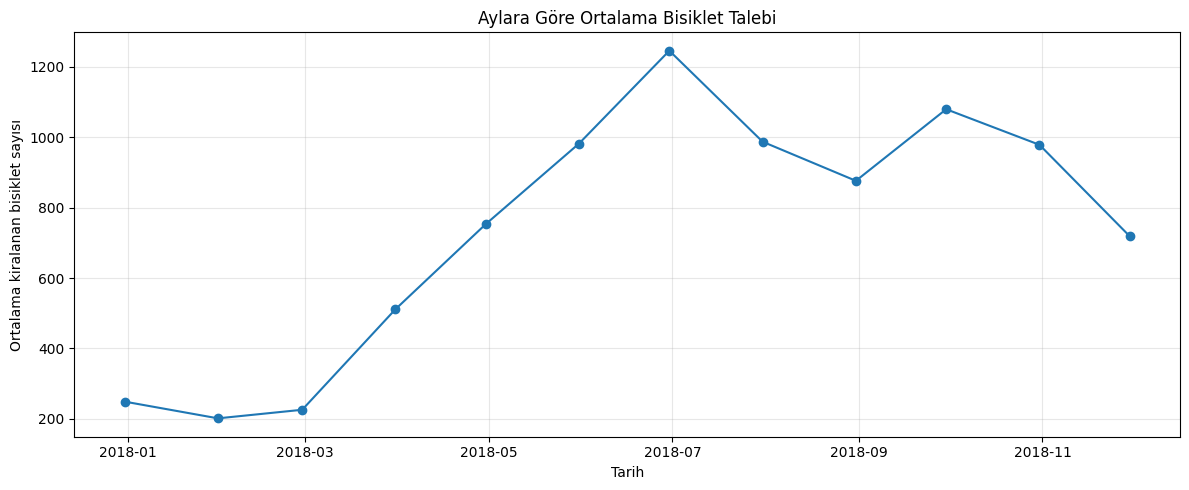

In [15]:
monthly_demand = (
    model_df
    .set_index("date")
    .resample("ME")["rented_bike_count"]
    .mean()
)

display(monthly_demand.to_frame("monthly_mean_demand"))

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o",
)
plt.title("Aylara Göre Ortalama Bisiklet Talebi")
plt.xlabel("Tarih")
plt.ylabel("Ortalama kiralanan bisiklet sayısı")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
holiday_normalized = (
    model_df["holiday"]
    .astype(str)
    .str.strip()
    .str.lower()
)

model_df["is_working_day"] = (
    (model_df["date"].dt.dayofweek < 5)
    & holiday_normalized.isin({"no holiday", "no_holiday"})
).astype(int)

model_df["morning_rush"] = (
    model_df["hour"].isin([7, 8, 9])
    & (model_df["is_working_day"] == 1)
).astype(int)

model_df["evening_rush"] = (
    model_df["hour"].isin([17, 18, 19])
    & (model_df["is_working_day"] == 1)
).astype(int)

model_df["temperature_squared"] = model_df["temperature_c"] ** 2
model_df["humidity_squared"] = model_df["humidity_pct"] ** 2

model_df["rain_flag"] = (
    model_df["rainfall_mm"] > 0
).astype(int)

model_df["snow_flag"] = (
    model_df["snowfall_cm"] > 0
).astype(int)

engineered_preview_columns = [
    "date",
    "hour",
    "is_working_day",
    "morning_rush",
    "evening_rush",
    "temperature_c",
    "temperature_squared",
    "humidity_pct",
    "humidity_squared",
    "rain_flag",
    "snow_flag",
    "days_since_start",
]

display(model_df[engineered_preview_columns].head(10))

,date,hour,is_working_day,morning_rush,evening_rush,temperature_c,temperature_squared,humidity_pct,humidity_squared,rain_flag,snow_flag,days_since_start
0,2017-12-01,0,1,0,0,-5.200,27.040,37,1369,0,0,0
1,2017-12-01,1,1,0,0,-5.500,30.250,38,1444,0,0,0
2,2017-12-01,2,1,0,0,-6.000,36.000,39,1521,0,0,0
3,2017-12-01,3,1,0,0,-6.200,38.440,40,1600,0,0,0
4,2017-12-01,4,1,0,0,-6.000,36.000,36,1296,0,0,0
5,2017-12-01,5,1,0,0,-6.400,40.960,37,1369,0,0,0
6,2017-12-01,6,1,0,0,-6.600,43.560,35,1225,0,0,0
7,2017-12-01,7,1,1,0,-7.400,54.760,38,1444,0,0,0
8,2017-12-01,8,1,1,0,-7.600,57.760,37,1369,0,0,0
9,2017-12-01,9,1,1,0,-6.500,42.250,27,729,0,0,0


In [17]:
TARGET_COLUMN = "rented_bike_count"

baseline_numeric_features = [
    "temperature_c",
    "humidity_pct",
    "wind_speed_m_s",
    "visibility_10m",
    "dew_point_temperature_c",
    "solar_radiation_mj_m2",
    "rainfall_mm",
    "snowfall_cm",
]

baseline_categorical_features = [
    "hour",
    "season",
    "holiday",
    "day_of_week",
    "is_weekend",
]

engineered_numeric_features = baseline_numeric_features + [
    "day_of_year_sin",
    "day_of_year_cos",
    "days_since_start",
    "is_working_day",
    "morning_rush",
    "evening_rush",
    "temperature_squared",
    "humidity_squared",
    "rain_flag",
    "snow_flag",
]

engineered_categorical_features = baseline_categorical_features.copy()

baseline_feature_columns = (
    baseline_numeric_features
    + baseline_categorical_features
)

engineered_feature_columns = (
    engineered_numeric_features
    + engineered_categorical_features
)

missing_columns = [
    column
    for column in engineered_feature_columns + [TARGET_COLUMN]
    if column not in model_df.columns
]

assert not missing_columns, f"Eksik sütunlar: {missing_columns}"
assert TARGET_COLUMN not in engineered_feature_columns

print("Baseline özellik sayısı:", len(baseline_feature_columns))
print("Geliştirilmiş özellik sayısı:", len(engineered_feature_columns))

Baseline özellik sayısı: 13
Geliştirilmiş özellik sayısı: 23


denetimli öğrenmede model hedefe giden ilişkiyi öğrenir

In [18]:
unique_dates = np.sort(model_df["date"].dt.normalize().unique())

split_position = int(len(unique_dates) * 0.80)
split_date = pd.Timestamp(unique_dates[split_position])

train_mask = model_df["date"] < split_date
test_mask = model_df["date"] >= split_date

train_df = model_df.loc[train_mask].copy()
test_df = model_df.loc[test_mask].copy()

X_train = train_df[engineered_feature_columns].copy()
X_test = test_df[engineered_feature_columns].copy()

y_train = train_df[TARGET_COLUMN].copy()
y_test = test_df[TARGET_COLUMN].copy()

print("Bölme tarihi:", split_date.date())
print()
print("Train tarih aralığı:")
print(train_df["date"].min(), "→", train_df["date"].max())
print("Train boyutu:", X_train.shape)
print()
print("Test tarih aralığı:")
print(test_df["date"].min(), "→", test_df["date"].max())
print("Test boyutu:", X_test.shape)

assert train_df["date"].max() < test_df["date"].min()
assert len(X_train) + len(X_test) == len(model_df)


Bölme tarihi: 2018-09-11

Train tarih aralığı:
2017-12-01 00:00:00 → 2018-09-10 00:00:00
Train boyutu: (6768, 23)

Test tarih aralığı:
2018-09-11 00:00:00 → 2018-11-30 00:00:00
Test boyutu: (1697, 23)


In [19]:
target_comparison = pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe(),
})

display(target_comparison)

print("Train hedef ortalaması:", y_train.mean())
print("Test hedef ortalaması:", y_test.mean())
print(
    "Ortalama farkı:",
    y_test.mean() - y_train.mean(),
)

,train,test
count,"6,768.000","1,697.000"
mean,687.620,894.814
std,646.156,599.127
min,2.000,2.000
25%,193.750,410.000
50%,444.000,834.000
75%,"1,027.000","1,233.000"
max,"3,556.000","3,277.000"


Train hedef ortalaması: 687.6204196217494
Test hedef ortalaması: 894.8137890394814
Ortalama farkı: 207.19336941773201


In [20]:
def make_one_hot_encoder():
    common_args = {
        "handle_unknown": "ignore",
        "drop": "first",
    }

    try:
        return OneHotEncoder(
            **common_args,
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            **common_args,
            sparse=False,
        )


def make_preprocessor(
    numeric_features,
    categorical_features,
    scale_numeric,
):
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(
        steps=numeric_steps
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "encoder",
                make_one_hot_encoder(),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(
    model,
    numeric_features,
    categorical_features,
    scale_numeric,
):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor(
                    numeric_features=numeric_features,
                    categorical_features=categorical_features,
                    scale_numeric=scale_numeric,
                ),
            ),
            ("model", model),
        ]
    )


print("Pipeline oluşturma fonksiyonları hazır.")

Pipeline oluşturma fonksiyonları hazır.


In [21]:
target_comparison = pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe(),
})

display(target_comparison)

print("Train hedef ortalaması:", y_train.mean())
print("Test hedef ortalaması:", y_test.mean())


,train,test
count,"6,768.000","1,697.000"
mean,687.620,894.814
std,646.156,599.127
min,2.000,2.000
25%,193.750,410.000
50%,444.000,834.000
75%,"1,027.000","1,233.000"
max,"3,556.000","3,277.000"


Train hedef ortalaması: 687.6204196217494
Test hedef ortalaması: 894.8137890394814


In [22]:
candidate_models = {
    "Dummy | Baseline": make_model_pipeline(
        model=DummyRegressor(strategy="mean"),
        numeric_features=baseline_numeric_features,
        categorical_features=baseline_categorical_features,
        scale_numeric=False,
    ),

    "Linear | Baseline": make_model_pipeline(
        model=LinearRegression(),
        numeric_features=baseline_numeric_features,
        categorical_features=baseline_categorical_features,
        scale_numeric=True,
    ),

    "Decision Tree | Baseline": make_model_pipeline(
        model=DecisionTreeRegressor(
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        ),
        numeric_features=baseline_numeric_features,
        categorical_features=baseline_categorical_features,
        scale_numeric=False,
    ),

    "Linear | Feature Engineering": make_model_pipeline(
        model=LinearRegression(),
        numeric_features=engineered_numeric_features,
        categorical_features=engineered_categorical_features,
        scale_numeric=True,
    ),

    "Ridge | Feature Engineering": make_model_pipeline(
        model=Ridge(alpha=1.0),
        numeric_features=engineered_numeric_features,
        categorical_features=engineered_categorical_features,
        scale_numeric=True,
    ),

    "Lasso | Feature Engineering": make_model_pipeline(
        model=Lasso(
            alpha=0.1,
            max_iter=30_000,
        ),
        numeric_features=engineered_numeric_features,
        categorical_features=engineered_categorical_features,
        scale_numeric=True,
    ),

    "Decision Tree | Feature Engineering": make_model_pipeline(
        model=DecisionTreeRegressor(
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        ),
        numeric_features=engineered_numeric_features,
        categorical_features=engineered_categorical_features,
        scale_numeric=False,
    ),

    "Random Forest | Feature Engineering": make_model_pipeline(
        model=RandomForestRegressor(
            n_estimators=200,
            max_depth=14,
            min_samples_leaf=4,
            max_features=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        numeric_features=engineered_numeric_features,
        categorical_features=engineered_categorical_features,
        scale_numeric=False,
    ),

    "Gradient Boosting | Feature Engineering": make_model_pipeline(
        model=GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
        ),
        numeric_features=engineered_numeric_features,
        categorical_features=engineered_categorical_features,
        scale_numeric=False,
    ),

    "Poisson | Feature Engineering": make_model_pipeline(
        model=PoissonRegressor(
            alpha=1.0,
            max_iter=3_000,
        ),
        numeric_features=engineered_numeric_features,
        categorical_features=engineered_categorical_features,
        scale_numeric=True,
    ),
}

model_feature_columns = {
    "Dummy | Baseline": baseline_feature_columns,
    "Linear | Baseline": baseline_feature_columns,
    "Decision Tree | Baseline": baseline_feature_columns,
    "Linear | Feature Engineering": engineered_feature_columns,
    "Ridge | Feature Engineering": engineered_feature_columns,
    "Lasso | Feature Engineering": engineered_feature_columns,
    "Decision Tree | Feature Engineering": engineered_feature_columns,
    "Random Forest | Feature Engineering": engineered_feature_columns,
    "Gradient Boosting | Feature Engineering": engineered_feature_columns,
    "Poisson | Feature Engineering": engineered_feature_columns,
}

print("Aday model sayısı:", len(candidate_models))

for model_name in candidate_models:
    print("-", model_name)

Aday model sayısı: 10
- Dummy | Baseline
- Linear | Baseline
- Decision Tree | Baseline
- Linear | Feature Engineering
- Ridge | Feature Engineering
- Lasso | Feature Engineering
- Decision Tree | Feature Engineering
- Random Forest | Feature Engineering
- Gradient Boosting | Feature Engineering
- Poisson | Feature Engineering


In [23]:
time_cv = TimeSeriesSplit(
    n_splits=5,
    gap=24,
)

cv_rows = []

for model_name, pipeline in candidate_models.items():
    print(f"CV çalışıyor: {model_name}")

    cv_mae_scores = -cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=time_cv,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
    )

    cv_rows.append({
        "Model": model_name,
        "CV_MAE_Mean": cv_mae_scores.mean(),
        "CV_MAE_Std": cv_mae_scores.std(),
        "CV_MAE_Min": cv_mae_scores.min(),
        "CV_MAE_Max": cv_mae_scores.max(),
    })

cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values("CV_MAE_Mean")
    .reset_index(drop=True)
)

display(cv_results_df)

CV çalışıyor: Dummy | Baseline
CV çalışıyor: Linear | Baseline
CV çalışıyor: Decision Tree | Baseline
CV çalışıyor: Linear | Feature Engineering
CV çalışıyor: Ridge | Feature Engineering
CV çalışıyor: Lasso | Feature Engineering
CV çalışıyor: Decision Tree | Feature Engineering
CV çalışıyor: Random Forest | Feature Engineering
CV çalışıyor: Gradient Boosting | Feature Engineering
CV çalışıyor: Poisson | Feature Engineering


,Model,CV_MAE_Mean,CV_MAE_Std,CV_MAE_Min,CV_MAE_Max
0,Gradient Boosting | Feature Engineering,255.924,105.308,73.322,386.072
1,Poisson | Feature Engineering,278.360,72.988,140.601,348.903
2,Random Forest | Feature Engineering,284.146,128.085,78.050,439.940
3,Decision Tree | Feature Engineering,334.470,155.075,79.326,511.590
4,Decision Tree | Baseline,335.081,144.330,85.655,485.125
5,Linear | Baseline,348.301,156.027,73.507,493.500
6,Ridge | Feature Engineering,379.721,182.694,154.280,668.695
7,Lasso | Feature Engineering,385.190,176.998,176.523,666.783
8,Linear | Feature Engineering,449.544,148.671,216.682,675.176
9,Dummy | Baseline,511.128,227.822,127.954,765.858


In [24]:
def calculate_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }


fitted_models = {}
holdout_rows = []

for model_name, pipeline in candidate_models.items():
    print(f"Eğitiliyor: {model_name}")

    fitted_pipeline = clone(pipeline)
    fitted_pipeline.fit(X_train, y_train)

    train_predictions = fitted_pipeline.predict(X_train)
    test_predictions = fitted_pipeline.predict(X_test)

    train_metrics = calculate_regression_metrics(
        y_train,
        train_predictions,
    )
    test_metrics = calculate_regression_metrics(
        y_test,
        test_predictions,
    )

    holdout_rows.append({
        "Model": model_name,
        "Train_MAE": train_metrics["MAE"],
        "Test_MAE": test_metrics["MAE"],
        "Train_RMSE": train_metrics["RMSE"],
        "Test_RMSE": test_metrics["RMSE"],
        "Train_R2": train_metrics["R2"],
        "Test_R2": test_metrics["R2"],
        "MAE_Gap": (
            test_metrics["MAE"]
            - train_metrics["MAE"]
        ),
        "Test_Train_MAE_Ratio": (
            test_metrics["MAE"]
            / train_metrics["MAE"]
            if train_metrics["MAE"] > 0
            else np.nan
        ),
    })

    fitted_models[model_name] = fitted_pipeline

holdout_results_df = pd.DataFrame(holdout_rows)

dummy_test_mae = holdout_results_df.loc[
    holdout_results_df["Model"] == "Dummy | Baseline",
    "Test_MAE",
].iloc[0]

holdout_results_df["Dummy_MAE_Improvement_%"] = (
    (
        dummy_test_mae
        - holdout_results_df["Test_MAE"]
    )
    / dummy_test_mae
    * 100
)

comparison_df = (
    cv_results_df
    .merge(
        holdout_results_df,
        on="Model",
        how="left",
    )
    .sort_values("CV_MAE_Mean")
    .reset_index(drop=True)
)

display(comparison_df)

Eğitiliyor: Dummy | Baseline
Eğitiliyor: Linear | Baseline
Eğitiliyor: Decision Tree | Baseline
Eğitiliyor: Linear | Feature Engineering
Eğitiliyor: Ridge | Feature Engineering
Eğitiliyor: Lasso | Feature Engineering
Eğitiliyor: Decision Tree | Feature Engineering
Eğitiliyor: Random Forest | Feature Engineering
Eğitiliyor: Gradient Boosting | Feature Engineering
Eğitiliyor: Poisson | Feature Engineering


,Model,CV_MAE_Mean,CV_MAE_Std,CV_MAE_Min,CV_MAE_Max,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,MAE_Gap,Test_Train_MAE_Ratio,Dummy_MAE_Improvement_%
0,Gradient Boosting | Feature Engineering,255.924,105.308,73.322,386.072,152.532,309.769,222.042,395.308,0.882,0.564,157.236,2.031,36.895
1,Poisson | Feature Engineering,278.360,72.988,140.601,348.903,143.834,338.986,219.331,431.273,0.885,0.482,195.152,2.357,30.943
2,Random Forest | Feature Engineering,284.146,128.085,78.050,439.940,86.356,250.581,144.714,339.347,0.950,0.679,164.226,2.902,48.953
3,Decision Tree | Feature Engineering,334.470,155.075,79.326,511.590,172.484,337.567,263.085,429.000,0.834,0.487,165.083,1.957,31.232
4,Decision Tree | Baseline,335.081,144.330,85.655,485.125,201.760,342.812,305.169,458.517,0.777,0.414,141.053,1.699,30.164
5,Linear | Baseline,348.301,156.027,73.507,493.500,287.060,254.215,379.132,345.158,0.656,0.668,-32.846,0.886,48.212
6,Ridge | Feature Engineering,379.721,182.694,154.280,668.695,252.842,514.287,329.564,586.765,0.740,0.040,261.444,2.034,-4.768
7,Lasso | Feature Engineering,385.190,176.998,176.523,666.783,252.675,515.581,329.595,587.991,0.740,0.036,262.905,2.040,-5.032
8,Linear | Feature Engineering,449.544,148.671,216.682,675.176,252.978,513.050,329.549,585.517,0.740,0.044,260.072,2.028,-4.517
9,Dummy | Baseline,511.128,227.822,127.954,765.858,515.972,490.880,646.108,633.775,0.000,-0.120,-25.092,0.951,0.000


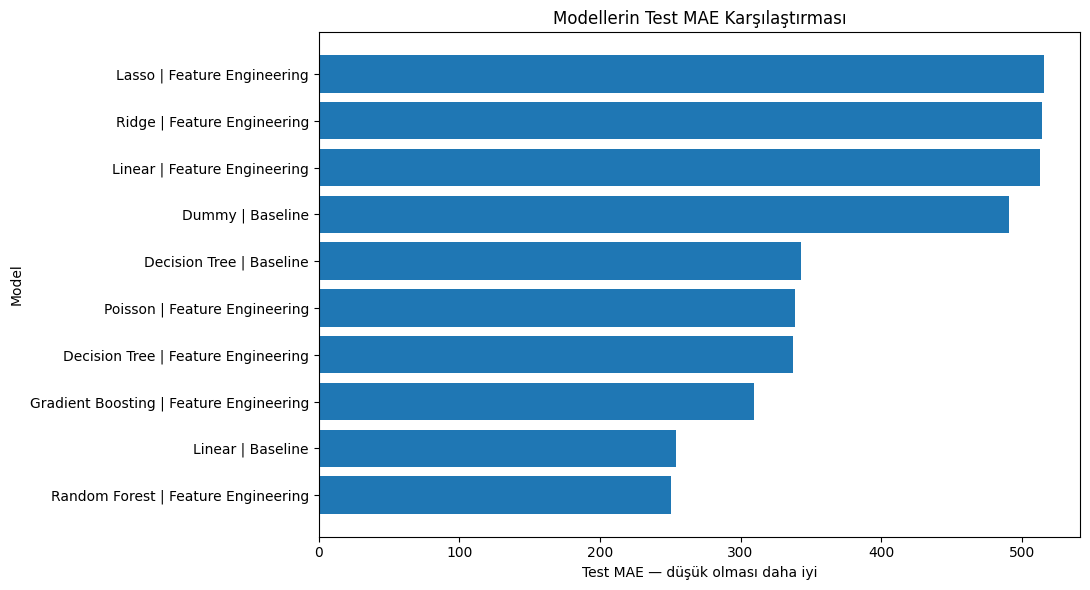

In [25]:
plot_df = (
    comparison_df
    .sort_values("Test_MAE", ascending=True)
)

plt.figure(figsize=(11, 6))
plt.barh(
    plot_df["Model"],
    plot_df["Test_MAE"],
)
plt.title("Modellerin Test MAE Karşılaştırması")
plt.xlabel("Test MAE — düşük olması daha iyi")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

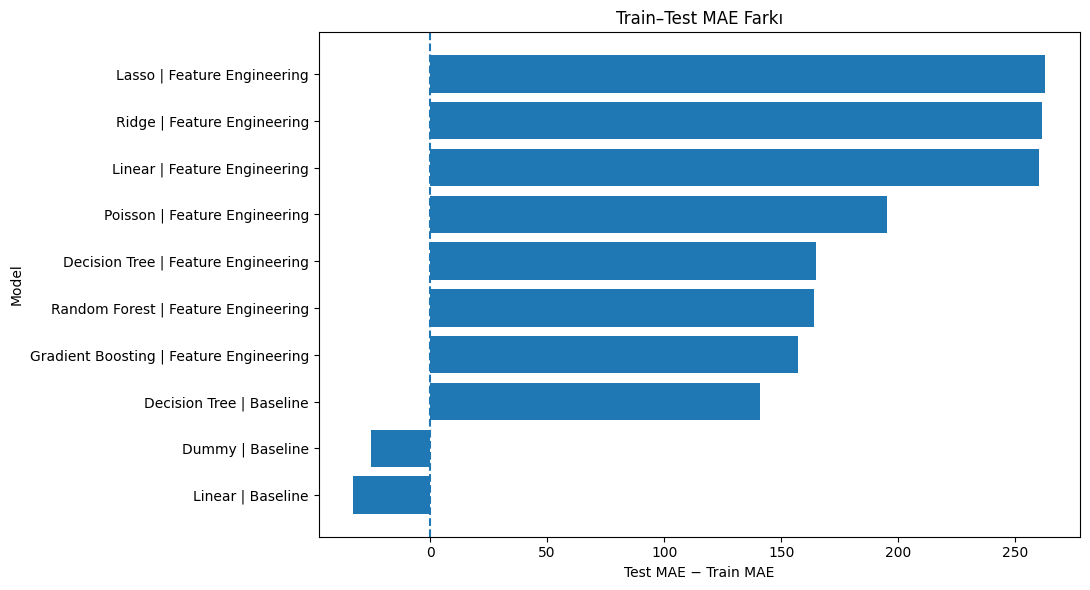

In [26]:
gap_plot_df = (
    comparison_df
    .sort_values("MAE_Gap", ascending=True)
)

plt.figure(figsize=(11, 6))
plt.barh(
    gap_plot_df["Model"],
    gap_plot_df["MAE_Gap"],
)
plt.axvline(0, linestyle="--")
plt.title("Train–Test MAE Farkı")
plt.xlabel("Test MAE − Train MAE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [27]:
tree_pipeline_for_search = make_model_pipeline(
    model=DecisionTreeRegressor(
        random_state=RANDOM_STATE,
    ),
    numeric_features=engineered_numeric_features,
    categorical_features=engineered_categorical_features,
    scale_numeric=False,
)

tree_param_grid = {
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_samples_split": [20, 50, 100],
    "model__min_samples_leaf": [10, 20, 50, 100],
}

tree_search = GridSearchCV(
    estimator=tree_pipeline_for_search,
    param_grid=tree_param_grid,
    scoring="neg_mean_absolute_error",
    cv=time_cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

tree_search.fit(X_train, y_train)

print("En iyi Decision Tree parametreleri:")
print(tree_search.best_params_)
print()
print(
    "En iyi CV MAE:",
    -tree_search.best_score_,
)

En iyi Decision Tree parametreleri:
{'model__max_depth': 8, 'model__min_samples_leaf': 10, 'model__min_samples_split': 50}

En iyi CV MAE: 337.0977585588092


In [28]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

time_cv = TimeSeriesSplit(
    n_splits=5,
    gap=24
)

gradient_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [5, 10, 20]
}

gradient_search = GridSearchCV(
    estimator=candidate_models[
        "Gradient Boosting | Feature Engineering"
    ],
    param_grid=gradient_param_grid,
    scoring="neg_mean_absolute_error",
    cv=time_cv,
    n_jobs=-1
)

gradient_search.fit(X_train, y_train)

print("En iyi parametreler:")
print(gradient_search.best_params_)

print("En iyi CV MAE:")
print(-gradient_search.best_score_)

En iyi parametreler:
{'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
En iyi CV MAE:
229.77939402482357


In [30]:
# Ayarlanmış modelleri burada toplayacağız.
# Hücrelerden biri çalıştırılmadıysa yalnızca mevcut olan model eklenir.

tuned_searches = {}

if "tree_search" in globals():
    tuned_searches[
        "Decision Tree | Tuned TimeSeriesCV"
    ] = tree_search

if "gradient_search" in globals():
    tuned_searches[
        "Gradient Boosting | Tuned TimeSeriesCV"
    ] = gradient_search


tuned_cv_rows = []
tuned_holdout_rows = []

for tuned_model_name, search_object in tuned_searches.items():

    print(f"Sonuçları hazırlanıyor: {tuned_model_name}")

    # GridSearchCV tarafından bulunan en iyi model
    tuned_model = search_object.best_estimator_

    # Train ve test tahminleri
    train_predictions = tuned_model.predict(X_train)
    test_predictions = tuned_model.predict(X_test)

    # Train ve test metrikleri
    train_metrics = calculate_regression_metrics(
        y_train,
        train_predictions,
    )

    test_metrics = calculate_regression_metrics(
        y_test,
        test_predictions,
    )

    # En iyi parametre kombinasyonunun indeksi
    best_index = search_object.best_index_

    # En iyi modelin her TimeSeriesSplit parçasındaki MAE değerleri
    split_score_columns = sorted(
        [
            column
            for column in search_object.cv_results_.keys()
            if column.startswith("split")
            and column.endswith("_test_score")
        ],
        key=lambda column: int(
            column.split("_")[0].replace("split", "")
        ),
    )

    split_mae_scores = np.array([
        -search_object.cv_results_[column][best_index]
        for column in split_score_columns
    ])

    tuned_cv_rows.append({
        "Model": tuned_model_name,
        "CV_MAE_Mean": split_mae_scores.mean(),
        "CV_MAE_Std": split_mae_scores.std(),
        "CV_MAE_Min": split_mae_scores.min(),
        "CV_MAE_Max": split_mae_scores.max(),
    })

    tuned_holdout_rows.append({
        "Model": tuned_model_name,
        "Train_MAE": train_metrics["MAE"],
        "Test_MAE": test_metrics["MAE"],
        "Train_RMSE": train_metrics["RMSE"],
        "Test_RMSE": test_metrics["RMSE"],
        "Train_R2": train_metrics["R2"],
        "Test_R2": test_metrics["R2"],

        "MAE_Gap": (
            test_metrics["MAE"]
            - train_metrics["MAE"]
        ),

        "Test_Train_MAE_Ratio": (
            test_metrics["MAE"]
            / train_metrics["MAE"]
            if train_metrics["MAE"] > 0
            else np.nan
        ),

        "Dummy_MAE_Improvement_%": (
            (
                dummy_test_mae
                - test_metrics["MAE"]
            )
            / dummy_test_mae
            * 100
        ),
    })

    # Eğitilmiş modeli daha sonra kullanmak üzere kaydet
    fitted_models[tuned_model_name] = tuned_model

    # Her iki ayarlanmış model de geliştirilmiş özellikleri kullanıyor
    model_feature_columns[
        tuned_model_name
    ] = engineered_feature_columns


tuned_cv_df = pd.DataFrame(tuned_cv_rows)
tuned_holdout_df = pd.DataFrame(tuned_holdout_rows)


# Hücre tekrar çalıştırılırsa aynı modellerin çoğalmasını engelle
tuned_model_names = list(tuned_searches.keys())

base_cv_results_df = cv_results_df.loc[
    ~cv_results_df["Model"].isin(tuned_model_names)
].copy()

base_holdout_results_df = holdout_results_df.loc[
    ~holdout_results_df["Model"].isin(tuned_model_names)
].copy()


cv_results_with_tuned_df = pd.concat(
    [
        base_cv_results_df,
        tuned_cv_df,
    ],
    ignore_index=True,
)

holdout_results_with_tuned_df = pd.concat(
    [
        base_holdout_results_df,
        tuned_holdout_df,
    ],
    ignore_index=True,
)


final_comparison_df = (
    cv_results_with_tuned_df
    .merge(
        holdout_results_with_tuned_df,
        on="Model",
        how="left",
    )
    .sort_values("CV_MAE_Mean")
    .reset_index(drop=True)
)

display(final_comparison_df)

Sonuçları hazırlanıyor: Decision Tree | Tuned TimeSeriesCV
Sonuçları hazırlanıyor: Gradient Boosting | Tuned TimeSeriesCV


,Model,CV_MAE_Mean,CV_MAE_Std,CV_MAE_Min,CV_MAE_Max,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,MAE_Gap,Test_Train_MAE_Ratio,Dummy_MAE_Improvement_%
0,Gradient Boosting | Tuned TimeSeriesCV,229.779,99.293,64.270,367.451,102.544,234.839,159.059,315.884,0.939,0.722,132.295,2.290,52.160
1,Gradient Boosting | Feature Engineering,255.924,105.308,73.322,386.072,152.532,309.769,222.042,395.308,0.882,0.564,157.236,2.031,36.895
2,Poisson | Feature Engineering,278.360,72.988,140.601,348.903,143.834,338.986,219.331,431.273,0.885,0.482,195.152,2.357,30.943
3,Random Forest | Feature Engineering,284.146,128.085,78.050,439.940,86.356,250.581,144.714,339.347,0.950,0.679,164.226,2.902,48.953
4,Decision Tree | Feature Engineering,334.470,155.075,79.326,511.590,172.484,337.567,263.085,429.000,0.834,0.487,165.083,1.957,31.232
5,Decision Tree | Baseline,335.081,144.330,85.655,485.125,201.760,342.812,305.169,458.517,0.777,0.414,141.053,1.699,30.164
6,Decision Tree | Tuned TimeSeriesCV,337.098,153.156,76.905,509.521,185.741,324.634,278.283,428.437,0.814,0.488,138.893,1.748,33.867
7,Linear | Baseline,348.301,156.027,73.507,493.500,287.060,254.215,379.132,345.158,0.656,0.668,-32.846,0.886,48.212
8,Ridge | Feature Engineering,379.721,182.694,154.280,668.695,252.842,514.287,329.564,586.765,0.740,0.040,261.444,2.034,-4.768
9,Lasso | Feature Engineering,385.190,176.998,176.523,666.783,252.675,515.581,329.595,587.991,0.740,0.036,262.905,2.040,-5.032


In [31]:
selection_table = final_comparison_df.loc[
    final_comparison_df["Model"] != "Dummy | Baseline"
].copy()

selection_table = selection_table.dropna(
    subset=["CV_MAE_Mean"]
)

selected_model_name = (
    selection_table
    .sort_values("CV_MAE_Mean")
    .iloc[0]["Model"]
)

selected_model = fitted_models[
    selected_model_name
]


selected_train_predictions = selected_model.predict(
    X_train
)

selected_test_predictions = selected_model.predict(
    X_test
)


selected_train_metrics = calculate_regression_metrics(
    y_train,
    selected_train_predictions,
)

selected_test_metrics = calculate_regression_metrics(
    y_test,
    selected_test_predictions,
)


selected_model_row = final_comparison_df.loc[
    final_comparison_df["Model"] == selected_model_name
].iloc[0]


print("FINAL MODEL")
print("=" * 65)

print("Model:", selected_model_name)

print(
    "CV MAE ortalaması:",
    round(selected_model_row["CV_MAE_Mean"], 3),
)

print(
    "CV MAE standart sapması:",
    round(selected_model_row["CV_MAE_Std"], 3),
)

print(
    "Train MAE:",
    round(selected_train_metrics["MAE"], 3),
)

print(
    "Test MAE:",
    round(selected_test_metrics["MAE"], 3),
)

print(
    "Test RMSE:",
    round(selected_test_metrics["RMSE"], 3),
)

print(
    "Train R²:",
    round(selected_train_metrics["R2"], 3),
)

print(
    "Test R²:",
    round(selected_test_metrics["R2"], 3),
)

FINAL MODEL
Model: Gradient Boosting | Tuned TimeSeriesCV
CV MAE ortalaması: 229.779
CV MAE standart sapması: 99.293
Train MAE: 102.544
Test MAE: 234.839
Test RMSE: 315.884
Train R²: 0.939
Test R²: 0.722


In [32]:
feature_comparison_pairs = {
    "Linear Regression": (
        "Linear | Baseline",
        "Linear | Feature Engineering",
    ),

    "Decision Tree": (
        "Decision Tree | Baseline",
        "Decision Tree | Feature Engineering",
    ),
}


feature_effect_rows = []

for algorithm_name, (
    baseline_name,
    engineered_name,
) in feature_comparison_pairs.items():

    baseline_row = final_comparison_df.loc[
        final_comparison_df["Model"] == baseline_name
    ]

    engineered_row = final_comparison_df.loc[
        final_comparison_df["Model"] == engineered_name
    ]

    if baseline_row.empty or engineered_row.empty:
        continue

    baseline_row = baseline_row.iloc[0]
    engineered_row = engineered_row.iloc[0]

    feature_effect_rows.append({
        "Algoritma": algorithm_name,

        "Baseline_CV_MAE": baseline_row[
            "CV_MAE_Mean"
        ],

        "Engineered_CV_MAE": engineered_row[
            "CV_MAE_Mean"
        ],

        "CV_MAE_Improvement_%": (
            (
                baseline_row["CV_MAE_Mean"]
                - engineered_row["CV_MAE_Mean"]
            )
            / baseline_row["CV_MAE_Mean"]
            * 100
        ),

        "Baseline_Test_MAE": baseline_row[
            "Test_MAE"
        ],

        "Engineered_Test_MAE": engineered_row[
            "Test_MAE"
        ],

        "Test_MAE_Improvement_%": (
            (
                baseline_row["Test_MAE"]
                - engineered_row["Test_MAE"]
            )
            / baseline_row["Test_MAE"]
            * 100
        ),

        "Baseline_Test_R2": baseline_row[
            "Test_R2"
        ],

        "Engineered_Test_R2": engineered_row[
            "Test_R2"
        ],

        "Test_R2_Change": (
            engineered_row["Test_R2"]
            - baseline_row["Test_R2"]
        ),
    })


feature_effect_df = pd.DataFrame(
    feature_effect_rows
)

display(feature_effect_df)

,Algoritma,Baseline_CV_MAE,Engineered_CV_MAE,CV_MAE_Improvement_%,Baseline_Test_MAE,Engineered_Test_MAE,Test_MAE_Improvement_%,Baseline_Test_R2,Engineered_Test_R2,Test_R2_Change
0,Linear Regression,348.301,449.544,-29.068,254.215,513.050,-101.818,0.668,0.044,-0.624
1,Decision Tree,335.081,334.470,0.182,342.812,337.567,1.530,0.414,0.487,0.073


görüldüğü gibi sonradan çıkarım yaptığımız özellikler doğrusal modelde işe yaramamış modeli daha kötü hale getirmiş fakat ilişkileri sadece doğrusal olarak anlamayan  modelde ise işimize yaramış buradan şu yola çıkabiliriz daha karmaşık ilişkileri bulabilecek modellerde bu çıkardığımız özellikler daha çok işe yaramıştır.

In [33]:
analysis_columns = [
    "date",
    "hour",
    "season",
    "holiday",
    "day_of_week",
    "is_weekend",
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "snowfall_cm",
]

analysis_columns = [
    column
    for column in analysis_columns
    if column in test_df.columns
]


error_df = test_df[
    analysis_columns
].copy()

error_df["actual"] = y_test.to_numpy()

error_df["predicted"] = (
    selected_test_predictions
)

error_df["residual"] = (
    error_df["actual"]
    - error_df["predicted"]
)

error_df["absolute_error"] = (
    error_df["residual"].abs()
)

error_df["squared_error"] = (
    error_df["residual"] ** 2
)


print("Ortalama residual:", error_df["residual"].mean())
print("Residual medyanı:", error_df["residual"].median())

print(
    "Negatif tahmin sayısı:",
    int((error_df["predicted"] < 0).sum()),
)

display(error_df.head())

Ortalama residual: 160.24603813756525
Residual medyanı: 140.90397405785757
Negatif tahmin sayısı: 12


,date,hour,season,holiday,day_of_week,is_weekend,temperature_c,humidity_pct,rainfall_mm,snowfall_cm,actual,predicted,residual,absolute_error,squared_error
6816,2018-09-11,0,Autumn,No Holiday,Tuesday,No,20.100,52,0.000,0.000,910,899.994,10.006,10.006,100.113
6817,2018-09-11,1,Autumn,No Holiday,Tuesday,No,19.500,52,0.000,0.000,662,897.873,-235.873,235.873,"55,635.886"
6818,2018-09-11,2,Autumn,No Holiday,Tuesday,No,18.900,52,0.000,0.000,435,612.832,-177.832,177.832,"31,624.120"
6819,2018-09-11,3,Autumn,No Holiday,Tuesday,No,18.200,52,0.000,0.000,261,465.741,-204.741,204.741,"41,918.867"
6820,2018-09-11,4,Autumn,No Holiday,Tuesday,No,17.700,52,0.000,0.000,193,421.497,-228.497,228.497,"52,210.953"


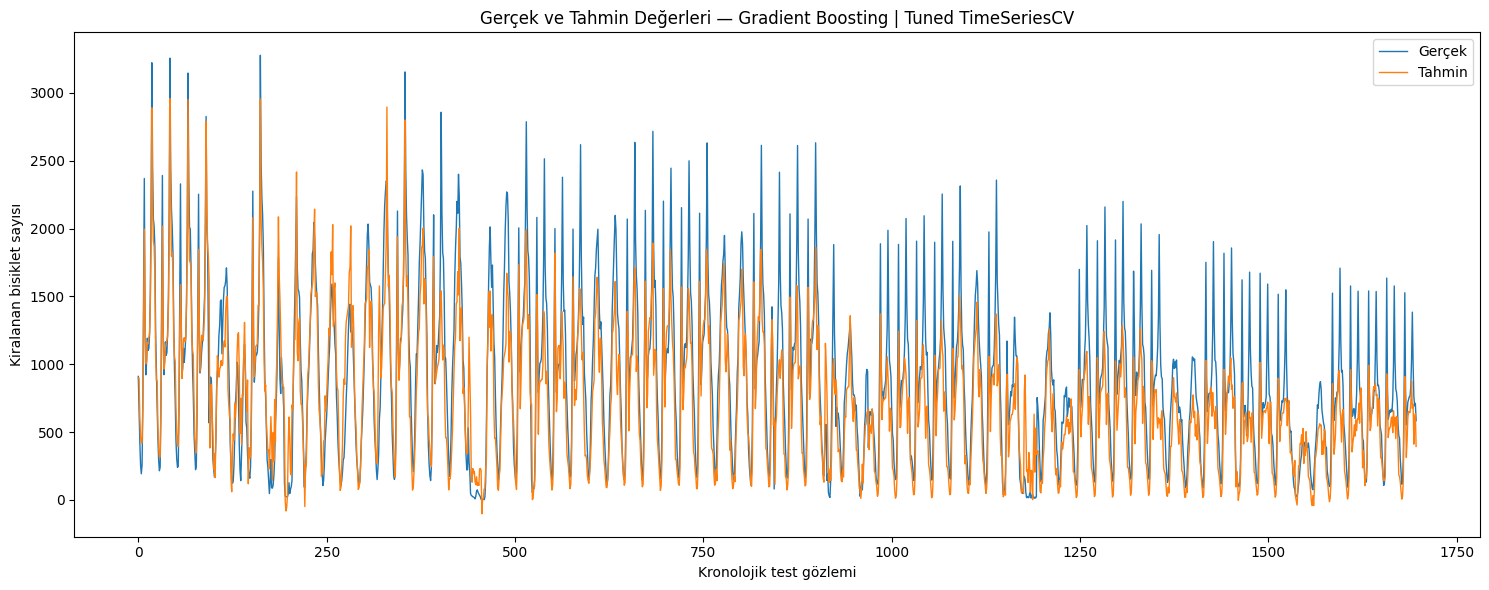

In [34]:
plot_error_df = (
    error_df
    .sort_values(["date", "hour"])
    .reset_index(drop=True)
)

plt.figure(figsize=(15, 6))

plt.plot(
    plot_error_df.index,
    plot_error_df["actual"],
    label="Gerçek",
    linewidth=1,
)

plt.plot(
    plot_error_df.index,
    plot_error_df["predicted"],
    label="Tahmin",
    linewidth=1,
)

plt.title(
    f"Gerçek ve Tahmin Değerleri — {selected_model_name}"
)

plt.xlabel("Kronolojik test gözlemi")
plt.ylabel("Kiralanan bisiklet sayısı")

plt.legend()
plt.tight_layout()
plt.show()

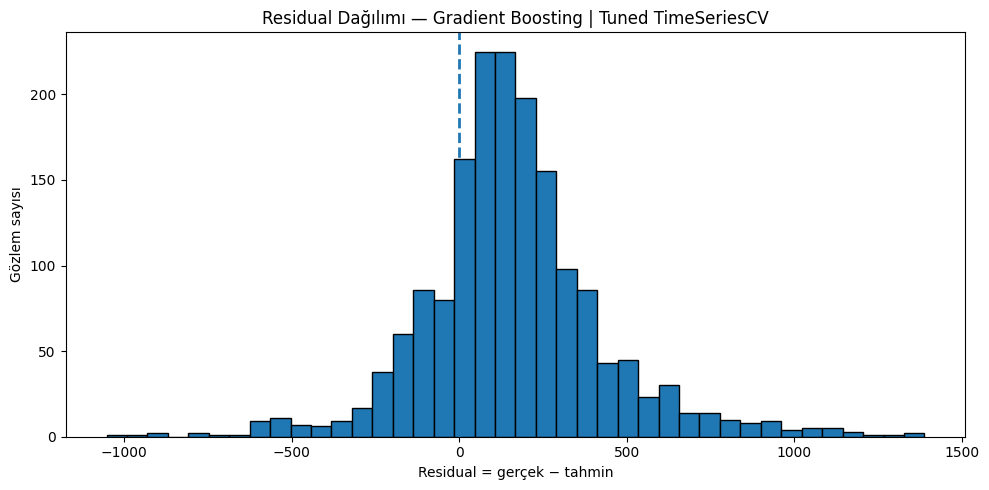

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(
    error_df["residual"],
    bins=40,
    edgecolor="black",
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
)

plt.title(
    f"Residual Dağılımı — {selected_model_name}"
)

plt.xlabel("Residual = gerçek − tahmin")
plt.ylabel("Gözlem sayısı")

plt.tight_layout()
plt.show()

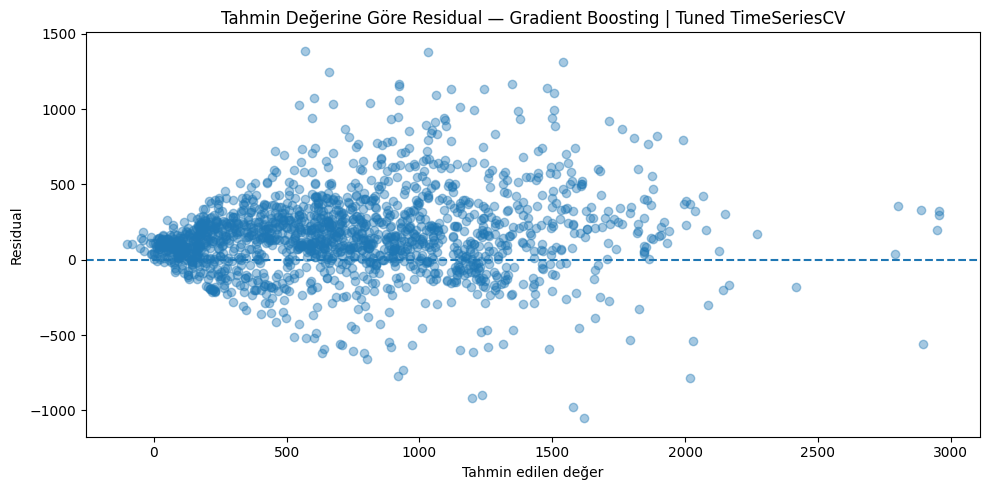

In [36]:
plt.figure(figsize=(10, 5))

plt.scatter(
    error_df["predicted"],
    error_df["residual"],
    alpha=0.4,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.title(
    f"Tahmin Değerine Göre Residual — {selected_model_name}"
)

plt.xlabel("Tahmin edilen değer")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

,hour,absolute_error
0,0,257.421
1,1,215.417
2,2,138.033
3,3,107.193
4,4,97.146
5,5,85.854
6,6,138.394
7,7,262.167
8,8,451.938
9,9,150.516


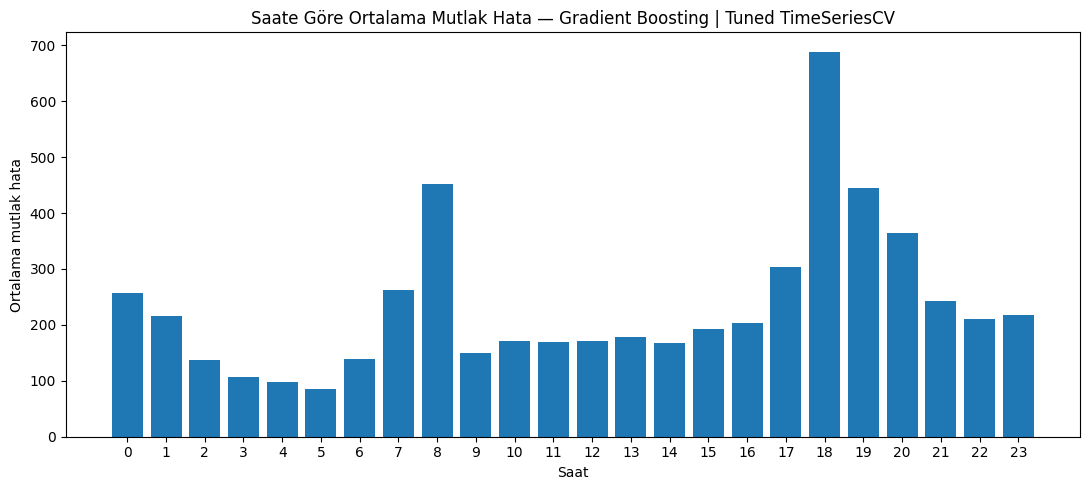

In [37]:
mae_by_hour = (
    error_df
    .groupby(
        "hour",
        as_index=False,
    )["absolute_error"]
    .mean()
)

display(mae_by_hour)


plt.figure(figsize=(11, 5))

plt.bar(
    mae_by_hour["hour"],
    mae_by_hour["absolute_error"],
)

plt.title(
    f"Saate Göre Ortalama Mutlak Hata — {selected_model_name}"
)

plt.xlabel("Saat")
plt.ylabel("Ortalama mutlak hata")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [38]:
largest_errors_df = (
    error_df
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(20)
)

print("Mutlak hatası en yüksek 20 gözlem:")

display(largest_errors_df)

Mutlak hatası en yüksek 20 gözlem:


,date,hour,season,holiday,day_of_week,is_weekend,temperature_c,humidity_pct,rainfall_mm,snowfall_cm,actual,predicted,residual,absolute_error,squared_error
8418,2018-11-16,18,Autumn,No Holiday,Friday,No,9.900,74,0.000,0.000,1956,568.121,"1,387.879","1,387.879","1,926,209.203"
7842,2018-10-23,18,Autumn,No Holiday,Tuesday,No,14.500,71,0.000,0.000,2415,"1,032.569","1,382.431","1,382.431","1,911,115.329"
7314,2018-10-01,18,Autumn,No Holiday,Monday,No,16.600,61,0.000,0.000,2857,"1,541.354","1,315.646","1,315.646","1,730,924.590"
8490,2018-11-19,18,Autumn,No Holiday,Monday,No,7.500,48,0.000,0.000,1904,659.729,"1,244.271","1,244.271","1,548,209.236"
8034,2018-10-31,18,Autumn,No Holiday,Wednesday,No,9.400,48,0.000,0.000,2094,924.561,"1,169.439","1,169.439","1,367,588.287"
7530,2018-10-10,18,Autumn,No Holiday,Wednesday,No,12.200,45,0.000,0.000,2514,"1,348.694","1,165.306","1,165.306","1,357,937.376"
8010,2018-10-30,18,Autumn,No Holiday,Tuesday,No,8.400,52,0.000,0.000,2074,922.771,"1,151.229","1,151.229","1,325,329.059"
7578,2018-10-12,18,Autumn,No Holiday,Friday,No,14.300,46,0.000,0.000,2618,"1,479.180","1,138.820","1,138.820","1,296,909.980"
8058,2018-11-01,18,Autumn,No Holiday,Thursday,No,11.800,43,0.000,0.000,2254,"1,117.908","1,136.092","1,136.092","1,290,705.140"
7554,2018-10-11,18,Autumn,No Holiday,Thursday,No,12.100,40,0.000,0.000,2378,"1,242.556","1,135.444","1,135.444","1,289,232.748"


In [39]:
selected_row = final_comparison_df.loc[
    final_comparison_df["Model"] == selected_model_name
].iloc[0]

dummy_row = final_comparison_df.loc[
    final_comparison_df["Model"] == "Dummy | Baseline"
].iloc[0]


dummy_improvement = (
    (
        dummy_row["Test_MAE"]
        - selected_row["Test_MAE"]
    )
    / dummy_row["Test_MAE"]
    * 100
)


hardest_hours = (
    mae_by_hour
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(3)["hour"]
    .astype(int)
    .tolist()
)


mean_residual = error_df["residual"].mean()

mae_ratio = (
    selected_row["Test_MAE"]
    / selected_row["Train_MAE"]
)


print("PROJE ÇIKARIM RAPORU")
print("=" * 72)

print(f"Final model: {selected_model_name}")

print(
    f"CV MAE: "
    f"{selected_row['CV_MAE_Mean']:.2f}"
)

print(
    f"Test MAE: "
    f"{selected_row['Test_MAE']:.2f}"
)

print(
    f"Test RMSE: "
    f"{selected_row['Test_RMSE']:.2f}"
)

print(
    f"Test R²: "
    f"{selected_row['Test_R2']:.3f}"
)

print(
    "Dummy modele göre Test MAE iyileşmesi: "
    f"%{dummy_improvement:.2f}"
)

print(
    "En yüksek ortalama hataya sahip saatler:",
    hardest_hours,
)

print(
    f"Ortalama residual: {mean_residual:.2f}"
)

print(
    f"Test / Train MAE oranı: {mae_ratio:.2f}"
)

print()


if mean_residual > 20:

    print(
        "• Ortalama residual pozitiftir. "
        "Model test döneminde genel olarak düşük tahmin "
        "etme eğilimindedir."
    )

elif mean_residual < -20:

    print(
        "• Ortalama residual negatiftir. "
        "Model test döneminde genel olarak yüksek tahmin "
        "etme eğilimindedir."
    )

else:

    print(
        "• Ortalama residual sıfıra yakındır. "
        "Belirgin bir genel tahmin yönü bulunmamaktadır."
    )


if mae_ratio > 1.50:

    print(
        "• Train ve test hataları arasında belirgin fark vardır. "
        "Overfitting veya dönemsel dağılım değişimi incelenmelidir."
    )

elif mae_ratio > 1.20:

    print(
        "• Test hatası train hatasından daha yüksektir; "
        "ancak fark aşırı seviyede değildir."
    )

else:

    print(
        "• Train ve test performansları birbirine görece yakındır."
    )


if selected_row["Test_R2"] < 0:

    print(
        "• Test R² negatiftir. Model test döneminde "
        "referans tahmine göre zayıf kalmıştır."
    )

elif selected_row["Test_R2"] < 0.50:

    print(
        "• Model anlamlı örüntüler öğrenmiştir; "
        "fakat açıklama gücü sınırlıdır."
    )

elif selected_row["Test_R2"] < 0.80:

    print(
        "• Model hedef değişkenliğinin önemli bir bölümünü "
        "açıklamaktadır."
    )

else:

    print(
        "• Model test döneminde güçlü bir açıklama "
        "performansı göstermektedir."
    )

PROJE ÇIKARIM RAPORU
Final model: Gradient Boosting | Tuned TimeSeriesCV
CV MAE: 229.78
Test MAE: 234.84
Test RMSE: 315.88
Test R²: 0.722
Dummy modele göre Test MAE iyileşmesi: %52.16
En yüksek ortalama hataya sahip saatler: [18, 8, 19]
Ortalama residual: 160.25
Test / Train MAE oranı: 2.29

• Ortalama residual pozitiftir. Model test döneminde genel olarak düşük tahmin etme eğilimindedir.
• Train ve test hataları arasında belirgin fark vardır. Overfitting veya dönemsel dağılım değişimi incelenmelidir.
• Model hedef değişkenliğinin önemli bir bölümünü açıklamaktadır.
